# 05 · Model Evaluation by ABC-XYZ Segment

Aggregate RMSE/MAPE is a weak signal — it hides *where* the forecast is good
or bad. Breaking validation error down by **ABC-XYZ cell** is the finding that
makes the analysis senior: it shows *why* the model performs differently on
different inventory types.

The numbers below come from `python -m src.evaluation`
(`outputs/segment_performance.csv`), which scores three forecasters per cell on
the held-out 28 days:

- **direct** — the deployed horizon-safe LightGBM model (`lgbm_v1.pkl`),
- **recursive** — the recursive multi-step model,
- **baseline** — the naive lag-7 seasonal forecast.

Segments are defined on the **training window** (revenue = units x price).

In [1]:
import sys

sys.path.append("..")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plotting import configure_matplotlib

configure_matplotlib()

## Segment performance table

One row per ABC-XYZ cell: SKU count, per-model RMSE/MAPE, the MTS/MTO policy,
and each model's RMSE improvement over the naive baseline.

In [3]:
table = pd.read_csv("../outputs/segment_performance.csv")
table

,abc_xyz,n_skus,n_obs,direct_rmse,direct_mape,recursive_rmse,recursive_mape,baseline_rmse,baseline_mape,abc_class,xyz_class,policy,direct_vs_baseline_pct,recursive_vs_baseline_pct
0,AX,1008,28224,3.5131,51.9295,3.4354,52.6898,4.4878,75.6520,A,X,MTS,21.7,23.5
1,AY,5173,144844,3.3933,55.7912,3.2107,55.7194,4.0106,81.5742,A,Y,MTS,15.4,19.9
2,AZ,1868,52304,3.6070,56.7287,3.2993,55.1919,4.1861,79.8896,A,Z,MTS,13.8,21.2
3,BX,148,4144,1.7373,49.3308,1.7519,50.6855,2.3840,84.1516,B,X,MTS,27.1,26.5
4,BY,4607,128996,1.8427,54.9013,1.8580,55.6604,2.5521,86.1636,B,Y,MTS,27.8,27.2
5,BZ,3946,110488,1.8308,55.5969,1.7773,53.8404,2.2653,82.7335,B,Z,MTS/review,19.2,21.5
6,CX,14,392,1.9082,46.0652,1.9084,54.4162,2.2874,84.0997,C,X,MTS,16.6,16.6
7,CY,1718,48104,1.4709,58.0806,1.4832,57.7758,2.0278,87.0715,C,Y,MTS/review,27.5,26.9
8,CZ,12008,336224,1.1075,62.2689,1.0954,59.7041,1.4139,84.4996,C,Z,MTO,21.7,22.5


## Key finding: RMSE measures volume, MAPE measures predictability

Two different stories, and the distinction is the point:

- **Absolute RMSE is dominated by demand *volume*, not predictability.** The
  high-value **A** cells have the *highest* RMSE (~3.4) simply because those SKUs
  sell the most units, so absolute errors are larger; the low-value **CZ** cell
  has the *lowest* RMSE (~1.1) because its demand is near zero. Ranking segments
  by raw RMSE is therefore misleading.
- **MAPE (relative error) reveals the predictability gradient.** It rises with
  demand variability X → Y → Z within every value tier, and **CZ is the single
  hardest cell (~62%)** — erratic, intermittent demand is genuinely the toughest
  to forecast, exactly as the ABC-XYZ framing predicts. The *variability* (XYZ)
  axis moves MAPE far more than the *value* (ABC) axis.

Both models beat the naive baseline in **every** cell (+14% to +28% RMSE), so the
model earns its keep across all inventory types — which is why Sprint 5 can set
*different service levels* per cell (99% for AX down to MTO for CZ).

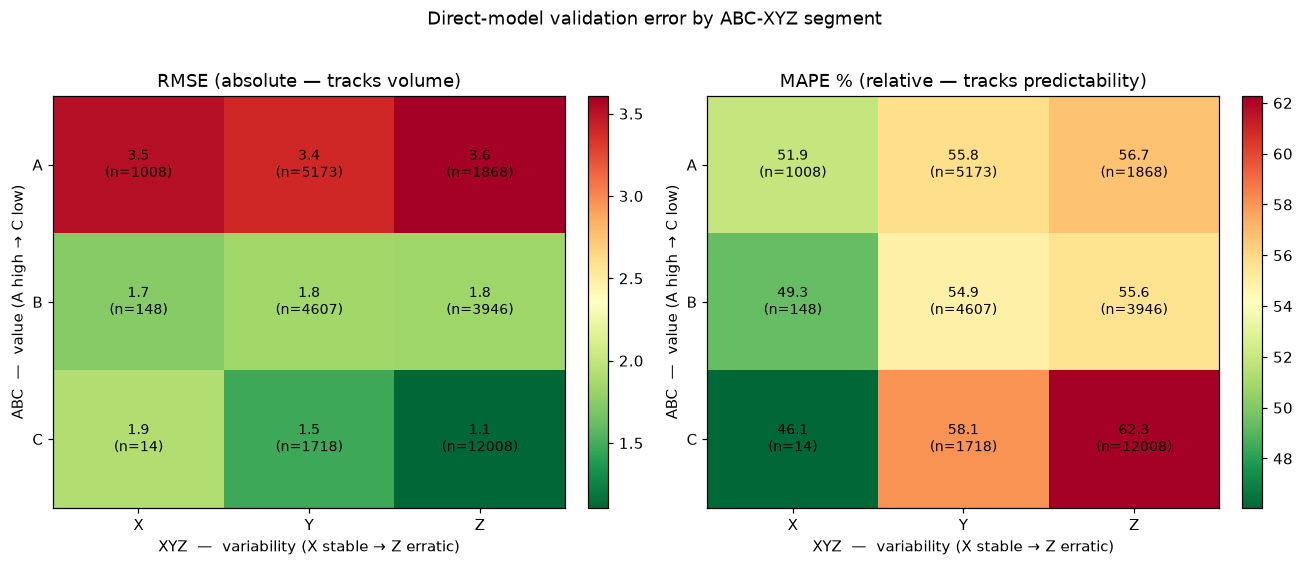

In [4]:
rows, cols = ["A", "B", "C"], ["X", "Y", "Z"]


def grid(col):
    return table.pivot(index="abc_class", columns="xyz_class", values=col).reindex(index=rows, columns=cols)


n_grid = grid("n_skus")
panels = [
    ("direct_rmse", "RMSE (absolute — tracks volume)"),
    ("direct_mape", "MAPE % (relative — tracks predictability)"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, title) in zip(axes, panels):
    g = grid(col)
    im = ax.imshow(g.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(3), cols)
    ax.set_yticks(range(3), rows)
    ax.set_xlabel("XYZ  —  variability (X stable → Z erratic)")
    ax.set_ylabel("ABC  —  value (A high → C low)")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            v, n = g.values[i, j], n_grid.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.1f}\n(n={int(n)})", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Direct-model validation error by ABC-XYZ segment", y=1.02)
fig.tight_layout()
fig.savefig("../outputs/segment_error_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Model vs. baseline lift by segment

Where does the model earn its keep? A positive lift means lower RMSE than the
naive lag-7 baseline. The lift is **positive in every cell** (+14% to +28%),
confirming the model beats a trivial forecaster across all inventory types.
Interestingly it's *smallest* on the high-value **A** cells (~14–15%), where
demand is large and the seasonal baseline is already a decent guess, and largest
on the moderate B/C cells. The recursive model adds a further edge on the
high-volume A cells, where the short lags it feeds back carry the most signal.

In [5]:
lift_cols = ["abc_xyz", "n_skus", "direct_rmse", "baseline_rmse", "direct_vs_baseline_pct"]
if "recursive_vs_baseline_pct" in table.columns:
    lift_cols[3:3] = ["recursive_rmse"]
    lift_cols.append("recursive_vs_baseline_pct")
table[lift_cols].sort_values("direct_vs_baseline_pct", ascending=False)

,abc_xyz,n_skus,direct_rmse,recursive_rmse,baseline_rmse,direct_vs_baseline_pct,recursive_vs_baseline_pct
4,BY,4607,1.8427,1.8580,2.5521,27.8,27.2
7,CY,1718,1.4709,1.4832,2.0278,27.5,26.9
3,BX,148,1.7373,1.7519,2.3840,27.1,26.5
0,AX,1008,3.5131,3.4354,4.4878,21.7,23.5
8,CZ,12008,1.1075,1.0954,1.4139,21.7,22.5
5,BZ,3946,1.8308,1.7773,2.2653,19.2,21.5
6,CX,14,1.9082,1.9084,2.2874,16.6,16.6
1,AY,5173,3.3933,3.2107,4.0106,15.4,19.9
2,AZ,1868,3.6070,3.2993,4.1861,13.8,21.2
